# 07. 处理多维特征的输入


列对应一个一个feature

神经网络就是模拟一个8维 -> 1维的非线性的空间变换，通过这个多层8->6->2->1类似这样的降维

泛化能力比较好

如果学的太多，可能会学到噪声，泛化不行

以人脸识别为例，如果你把一张图片丢给一个多层神经网络，它的内部是这样分工的：

 - 第 1 层（底层）： 只负责看最简单的东西。比如它只提取出图像中的边缘、线条、明暗色块。

 - 第 2 层（中层）： 它不会从头看图片，而是基于第 1 层提取出的线条，把它们组合起来，识别出眼睛、鼻子、嘴巴等局部轮廓。

 - 第 3 层（高层）： 基于第 2 层的眼睛和鼻子，它进一步组合，识别出这是一张完整的人脸。

 - 第 N 层（输出）： 告诉你这个人是张三还是李四。



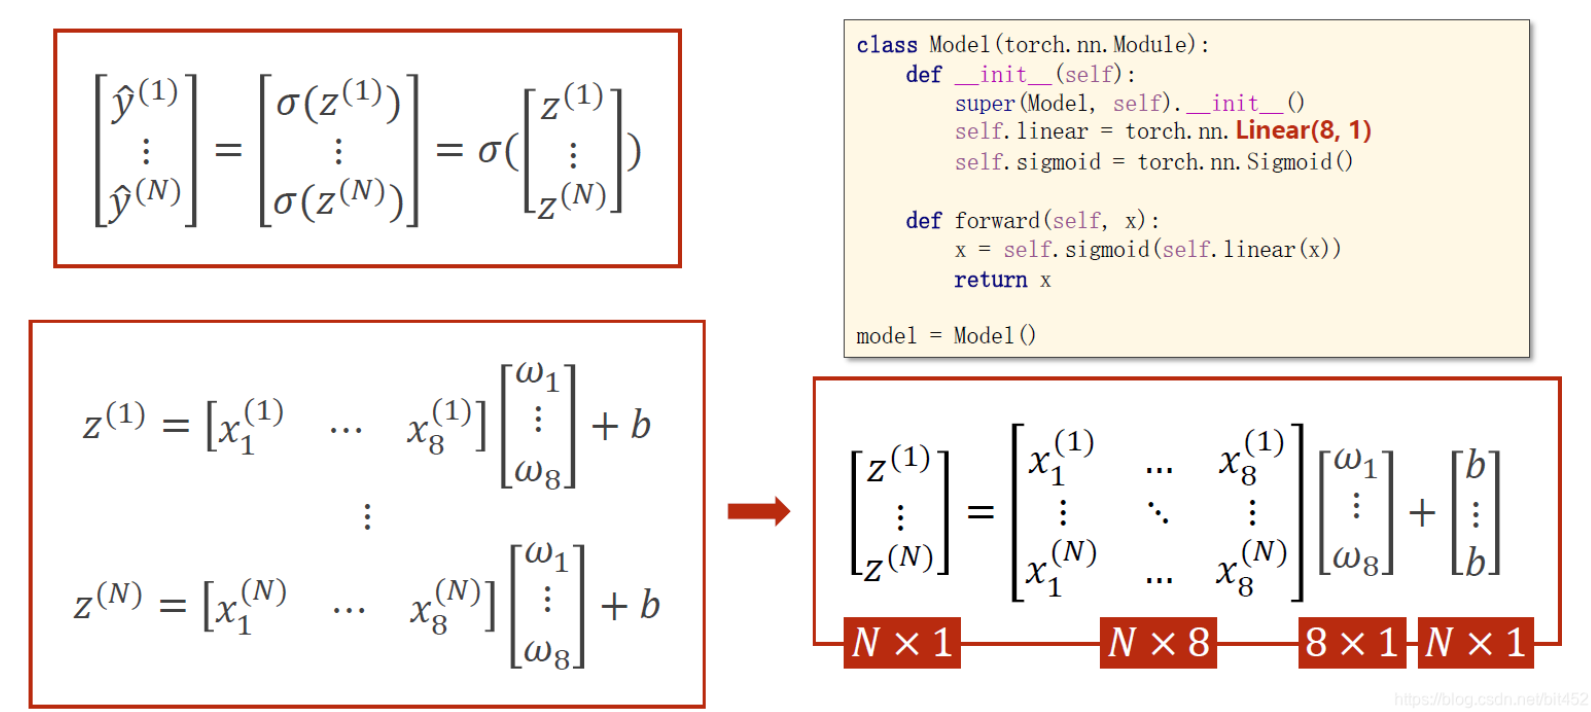

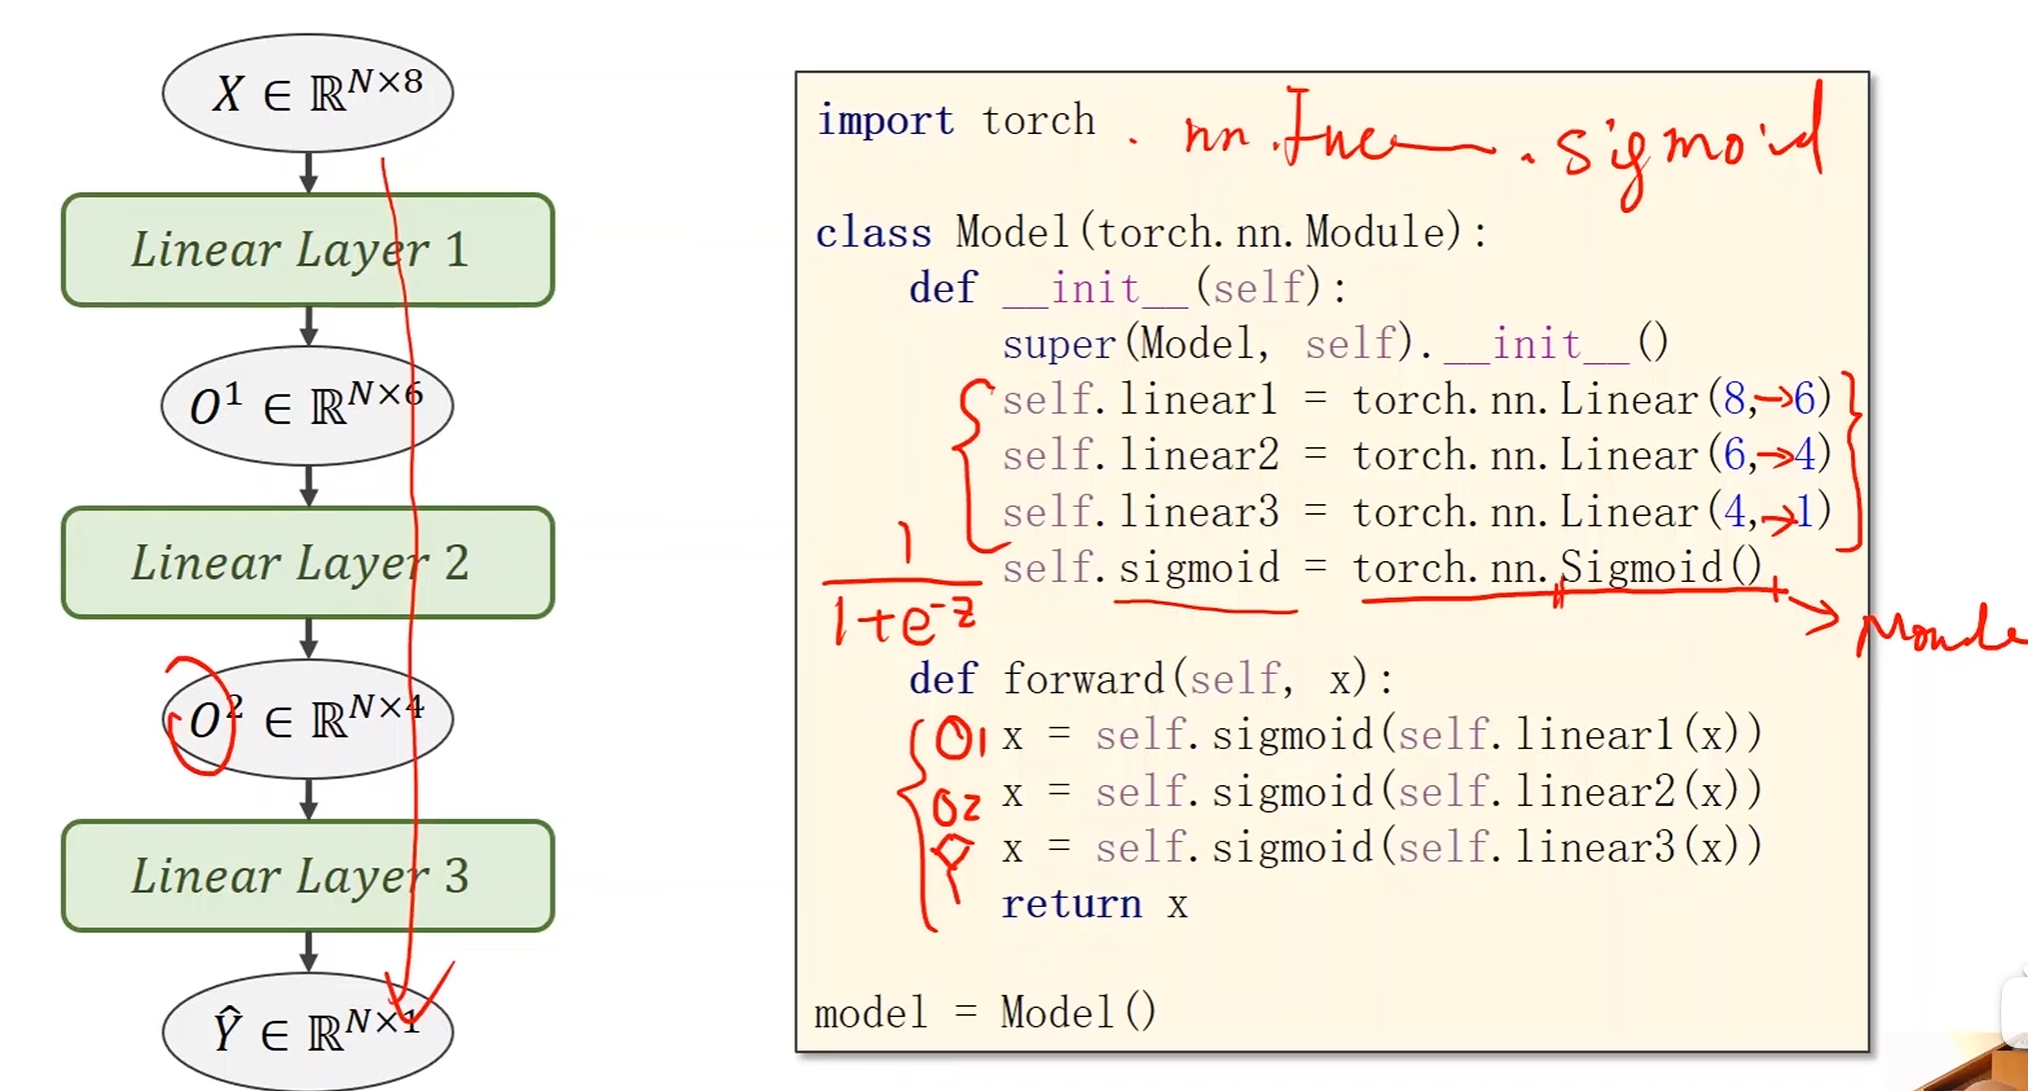

说明：
- 乘的权重(w)都一样，加的偏置(b)也一样。b变成矩阵时使用广播机制。神经网络的参数w和b是网络需要学习的，其他是已知的。

- 学习能力越强，有可能会把输入样本中噪声的规律也学到。我们要学习数据本身真实数据的规律，学习能力要有泛化能力。

- 该神经网络共3层；第一层是8维到6维的非线性空间变换，第二层是6维到4维的非线性空间变换，第三层是4维到1维的非线性空间变换。

- 本算法中torch.nn.Sigmoid() # 将其看作是网络的一层，而不是简单的函数使用 。虽然但是gpt说这里也可以不用nn依然只在下面用torch.sigmoid函数
- 除此以外还有很多激活函数，可以换成torch.nn.ReLU()

0 0.7164361476898193
1 0.7096583247184753
2 0.7035377025604248
3 0.6980093121528625
4 0.6930150389671326
5 0.6885021328926086
6 0.6844233870506287
7 0.6807358860969543
8 0.6774014830589294
9 0.6743851900100708
10 0.6716560125350952
11 0.6691859364509583
12 0.6669496297836304
13 0.6649243831634521
14 0.6630898118019104
15 0.6614274382591248
16 0.6599206328392029
17 0.6585544347763062
18 0.6573154330253601
19 0.6561914682388306
20 0.6551715731620789
21 0.6542457938194275
22 0.6534053683280945
23 0.6526421904563904
24 0.6519489288330078
25 0.6513190269470215
26 0.6507467031478882
27 0.6502264142036438
28 0.6497534513473511
29 0.6493232846260071
30 0.6489320397377014
31 0.6485761404037476
32 0.6482523083686829
33 0.6479576230049133
34 0.6476894021034241
35 0.6474450826644897
36 0.6472227573394775
37 0.6470202803611755
38 0.6468357443809509
39 0.6466676592826843
40 0.6465145945549011
41 0.6463750004768372
42 0.6462478041648865
43 0.6461318731307983
44 0.6460261344909668
45 0.645929694175720

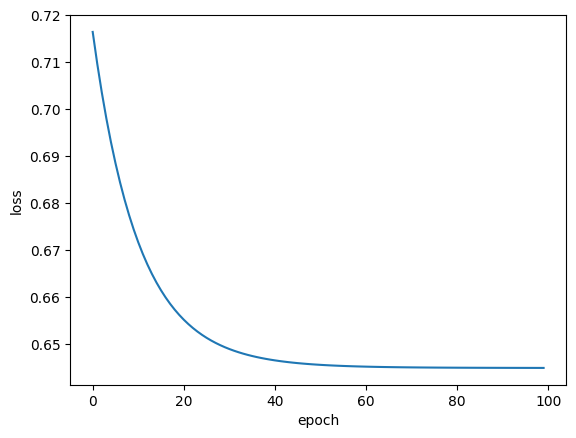

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
 
# prepare dataset
xy = np.loadtxt('diabetes.csv', delimiter=',', dtype=np.float32)
x_data = torch.from_numpy(xy[:, :-1]) # 第一个‘：’是指读取所有行，第二个‘：’是指从第一列开始，最后一列不要
y_data = torch.from_numpy(xy[:, [-1]]) # [-1] 最后得到的是个矩阵
 
# design model using class
 
 
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 6) # 输入数据x的特征是8维，x有8个特征
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 1)
        self.sigmoid = torch.nn.Sigmoid() # 将其看作是网络的一层，而不是简单的函数使用
 
    def forward(self, x):
        x = self.sigmoid(self.linear1(x))
        x = self.sigmoid(self.linear2(x))
        x = self.sigmoid(self.linear3(x)) # y hat
        return x
 
 
model = Model()
 
# construct loss and optimizer
# criterion = torch.nn.BCELoss(size_average = True)
criterion = torch.nn.BCELoss(reduction='mean')  
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
 
epoch_list = []
loss_list = []
# training cycle forward, backward, update
for epoch in range(100):
    y_pred = model(x_data) #这里用了全部的数据，一整个batch
    loss = criterion(y_pred, y_data)

    print(epoch, loss.item())
    epoch_list.append(epoch)
    loss_list.append(loss.item())
 
    optimizer.zero_grad()
    loss.backward()
 
    optimizer.step()
 
 
plt.plot(epoch_list, loss_list)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()